# Luftkvalitet i Malmö – Dalaplan och Rådhuset

Data hämtas från Naturvårdsverkets REST-API för luftkvalitetsdata, som tillhandahålls av SMHI (datavärd för luft).

- **Dalaplan** är en *gaturumsstation*: den mäter mitt i trafikmiljön.
- **Rådhuset** är en *urban bakgrundsstation*: den mäter den allmänna luften i staden, på taket av Rådhuset.

Obs: senaste värdena är **realtidsdata** som ännu inte är kvalitetssäkrade.

In [9]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta

pd.set_option("display.width", 200)

BASE = "https://datavardluft.smhi.se/52North/api"

# I API:et motsvarar varje "station-id" ett ämne på en plats
STATIONER = {
    "Dalaplan": [271, 272, 273, 274, 275, 276, 278, 412, 4131, 5750],
    "Rådhuset": [117, 118, 120, 121, 122, 123, 125, 4256, 5513, 5528],
}

AMNEN = {
    "NO2": "Kvävedioxid (NO2)",
    "NOX as NO2": "Kväveoxider (NOx)",
    "O3": "Ozon (O3)",
    "PM10": "Partiklar PM10",
    "PM2.5": "Partiklar PM2,5",
    "CO": "Kolmonoxid (CO)",
    "SO2": "Svaveldioxid (SO2)",
    "C6H6": "Bensen",
    "C6H5-CH3": "Toluen",
    "Black Carbon": "Sot (Black Carbon)",
    "UFPs": "Ultrafina partiklar",
}

def hamta(url, **params):
    svar = requests.get(url, params=params, timeout=30)
    svar.raise_for_status()
    return svar.json()

def till_svensk_tid(ms):
    tid = pd.to_datetime(ms, unit="ms", utc=True)
    if isinstance(tid, pd.Series):
        return tid.dt.tz_convert("Europe/Stockholm")
    return tid.tz_convert("Europe/Stockholm")

## 1. Stationerna

In [2]:
station = hamta(f"{BASE}/stations/276")
rad_dalaplan = {"plats": "Dalaplan", "typ": station["properties"]["classification"],
                "lon": station["geometry"]["coordinates"][0], "lat": station["geometry"]["coordinates"][1]}

station = hamta(f"{BASE}/stations/121")
rad_radhuset = {"plats": "Rådhuset", "typ": station["properties"]["classification"],
                "lon": station["geometry"]["coordinates"][0], "lat": station["geometry"]["coordinates"][1]}

pd.DataFrame([rad_dalaplan, rad_radhuset])

,plats,typ,lon,lat
0,Dalaplan,Gaturum,13.006230,55.584747
1,Rådhuset,Urban bakgrund,13.001964,55.606388


## 2. Hämta alla tidsserier för båda stationerna

Varje ämne kan ha flera tidsserier, till exempel när ett instrument har bytts ut. Vi hämtar alla och markerar vilka som fortfarande är aktiva. Det tar ungefär en halv minut.

In [3]:
rader = []
for plats, station_ids in STATIONER.items():
    for station_id in station_ids:
        try:
            station = hamta(f"{BASE}/stations/{station_id}")
        except Exception as e:
            print(f"Kunde inte hämta station {station_id}: {e}")
            continue
        for ts_id in station["properties"]["timeseries"]:
            try:
                ts = hamta(f"{BASE}/timeseries/{ts_id}")
            except Exception as e:
                print(f"Kunde inte hämta tidsserie {ts_id}: {e}")
                continue
            kod = ts["parameters"]["phenomenon"]["label"]
            rader.append({
                "plats": plats,
                "ämne_kod": kod,
                "ämne": AMNEN.get(kod, kod),
                "tidsserie_id": ts_id,
                "enhet": ts.get("uom"),
                "första_mätning": till_svensk_tid(ts["firstValue"]["timestamp"]) if ts.get("firstValue") else None,
                "senaste_mätning": till_svensk_tid(ts["lastValue"]["timestamp"]) if ts.get("lastValue") else None,
                "senaste_värde": ts["lastValue"]["value"] if ts.get("lastValue") else None,
            })

tidsserier = pd.DataFrame(rader)

# En tidsserie räknas som aktiv om den har data från de senaste två dygnen
grans = pd.Timestamp.now(tz="Europe/Stockholm") - pd.Timedelta(days=2)
tidsserier["aktiv"] = tidsserier["senaste_mätning"] > grans

print(f"{len(tidsserier)} tidsserier totalt, varav {tidsserier['aktiv'].sum()} aktiva")

32 tidsserier totalt, varav 14 aktiva


## 3. Vilka ämnen mäts idag på respektive station?

In [4]:
aktiva = tidsserier[tidsserier["aktiv"]].copy()

oversikt = pd.crosstab(aktiva["ämne"], aktiva["plats"]).astype(bool).replace({True: "✓", False: ""})
oversikt

plats,Dalaplan,Rådhuset
ämne,,
Bensen,✓,
Kolmonoxid (CO),✓,
Kvävedioxid (NO2),✓,✓
Ozon (O3),✓,✓
Partiklar PM10,✓,✓
"Partiklar PM2,5",✓,✓
Sot (Black Carbon),✓,✓
Svaveldioxid (SO2),,✓
Ultrafina partiklar,✓,


## 4. Senaste mätningen

In [5]:
senaste = aktiva[["plats", "ämne", "senaste_värde", "enhet", "senaste_mätning"]].copy()
senaste["senaste_mätning"] = senaste["senaste_mätning"].dt.strftime("%Y-%m-%d %H:%M")
senaste.sort_values(["ämne", "plats"]).reset_index(drop=True)

,plats,ämne,senaste_värde,enhet,senaste_mätning
0,Dalaplan,Bensen,0.80,µg/m3,2026-09-28 21:00
1,Dalaplan,Kolmonoxid (CO),0.79,µg/m3,2026-09-28 21:00
2,Dalaplan,Kvävedioxid (NO2),39.40,µg/m3,2026-09-28 20:00
3,Rådhuset,Kvävedioxid (NO2),16.10,µg/m3,2026-09-28 21:00
4,Dalaplan,Ozon (O3),37.00,µg/m3,2026-09-28 21:00
5,Rådhuset,Ozon (O3),39.60,µg/m3,2026-09-28 21:00
6,Dalaplan,Partiklar PM10,25.70,µg/m3,2026-09-28 21:00
7,Rådhuset,Partiklar PM10,16.90,µg/m3,2026-09-28 21:00
8,Dalaplan,"Partiklar PM2,5",13.30,µg/m3,2026-09-28 21:00
9,Rådhuset,"Partiklar PM2,5",10.60,µg/m3,2026-09-28 21:00


Samma sak som en jämförelse sida vid sida:

In [6]:
aktiva.pivot_table(index="ämne", columns="plats", values="senaste_värde").round(1)

plats,Dalaplan,Rådhuset
ämne,,
Bensen,0.8,NaN
Kolmonoxid (CO),0.8,NaN
Kvävedioxid (NO2),39.4,16.1
Ozon (O3),37.0,39.6
Partiklar PM10,25.7,16.9
"Partiklar PM2,5",13.3,10.6
Sot (Black Carbon),0.8,0.8
Svaveldioxid (SO2),NaN,0.9
Ultrafina partiklar,7503.8,NaN


## 5. Hur lång historik finns?

Första mätningen i den *aktiva* tidsserien. För partiklar kan det finnas äldre tidsserier från tidigare instrument som går att skarva ihop.

In [7]:
historik = aktiva[["plats", "ämne", "första_mätning"]].copy()
historik["år_med_data"] = ((pd.Timestamp.now(tz="Europe/Stockholm") - historik["första_mätning"]).dt.days / 365.25).round(1)
historik["första_mätning"] = historik["första_mätning"].dt.strftime("%Y-%m-%d")
historik.sort_values(["ämne", "plats"]).reset_index(drop=True)

,plats,ämne,första_mätning,år_med_data
0,Dalaplan,Bensen,2006-01-01,20.7
1,Dalaplan,Kolmonoxid (CO),2012-02-03,14.7
2,Dalaplan,Kvävedioxid (NO2),1999-11-05,26.9
3,Rådhuset,Kvävedioxid (NO2),1998-01-01,28.7
4,Dalaplan,Ozon (O3),2006-01-01,20.7
5,Rådhuset,Ozon (O3),1998-01-01,28.7
6,Dalaplan,Partiklar PM10,2023-01-01,3.7
7,Rådhuset,Partiklar PM10,2022-01-01,4.7
8,Dalaplan,"Partiklar PM2,5",2023-05-26,3.3
9,Rådhuset,"Partiklar PM2,5",2022-01-01,4.7


## 6. Kvävedioxid senaste veckan 

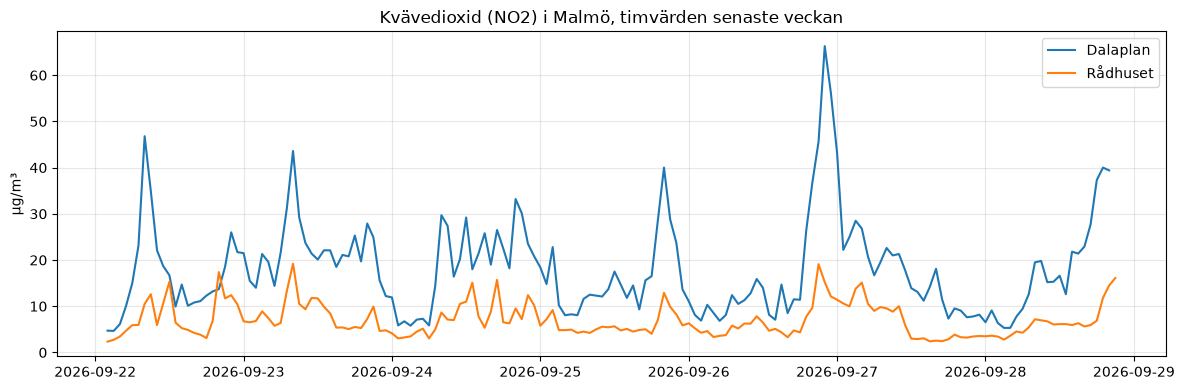

In [11]:
slut = (date.today() + timedelta(days=1)).isoformat()
no2 = aktiva[aktiva["ämne_kod"] == "NO2"]

fig, ax = plt.subplots(figsize=(12, 4))
for _, rad in no2.iterrows():
    data = hamta(f"{BASE}/timeseries/{rad['tidsserie_id']}/getData", timespan=f"P7D/{slut}")
    df = pd.DataFrame(data["values"])
    df["tid"] = till_svensk_tid(df["timestamp"])
    ax.plot(df["tid"], df["value"], label=rad["plats"])

ax.set_title("Kvävedioxid (NO2) i Malmö, timvärden senaste veckan")
ax.set_ylabel("µg/m³")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

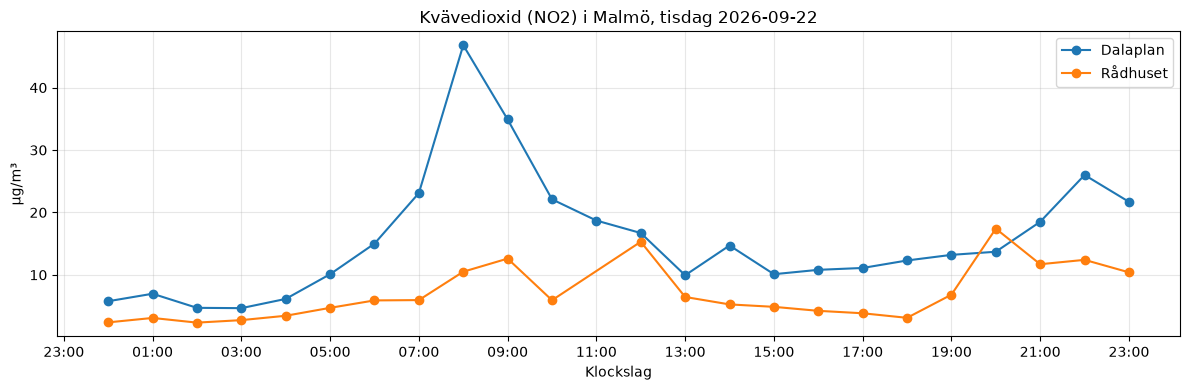

In [12]:
import matplotlib.dates as mdates

# Hitta förra tisdagen (weekday: måndag = 0, tisdag = 1)
idag = date.today()
dagar_sedan = (idag.weekday() - 1) % 7 or 7
tisdag = idag - timedelta(days=dagar_sedan)

# Hämta några dagar runt tisdagen och filtrera sedan ut dygnet i svensk tid,
# så att vi slipper krångel med UTC vid dygnsgränserna
slut = (tisdag + timedelta(days=2)).isoformat()

fig, ax = plt.subplots(figsize=(12, 4))
for _, rad in no2.iterrows():
    data = hamta(f"{BASE}/timeseries/{rad['tidsserie_id']}/getData", timespan=f"P4D/{slut}")
    df = pd.DataFrame(data["values"])
    df["tid"] = till_svensk_tid(df["timestamp"])
    df = df[df["tid"].dt.date == tisdag]
    ax.plot(df["tid"], df["value"], marker="o", label=rad["plats"])

ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz="Europe/Stockholm"))
ax.set_title(f"Kvävedioxid (NO2) i Malmö, tisdag {tisdag.isoformat()}")
ax.set_xlabel("Klockslag")
ax.set_ylabel("µg/m³")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

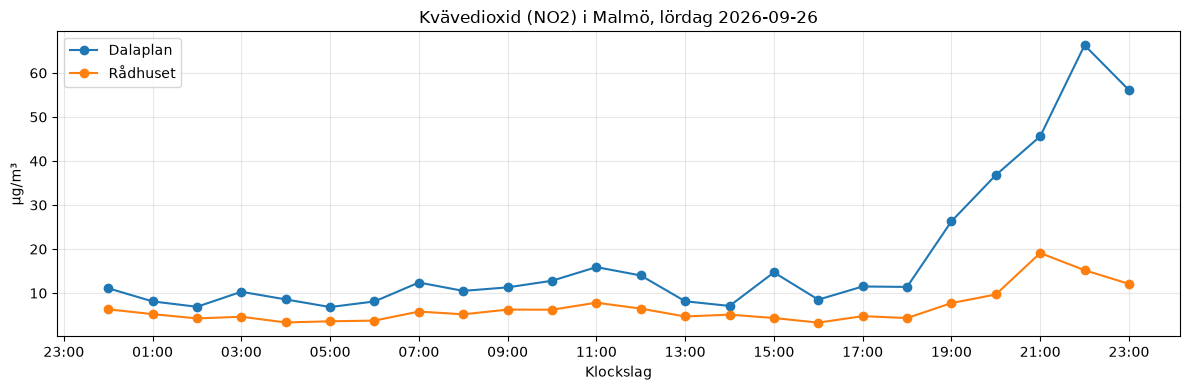

In [16]:
def rita_dygn(dag):
    slut = (dag + timedelta(days=2)).isoformat()

    fig, ax = plt.subplots(figsize=(12, 4))
    for _, rad in no2.iterrows():
        data = hamta(f"{BASE}/timeseries/{rad['tidsserie_id']}/getData", timespan=f"P4D/{slut}")
        df = pd.DataFrame(data["values"])
        df["tid"] = till_svensk_tid(df["timestamp"])
        df = df[df["tid"].dt.date == dag]
        ax.plot(df["tid"], df["value"], marker="o", label=rad["plats"])

    veckodagar = ["måndag", "tisdag", "onsdag", "torsdag", "fredag", "lördag", "söndag"]
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz="Europe/Stockholm"))
    ax.set_title(f"Kvävedioxid (NO2) i Malmö, {veckodagar[dag.weekday()]} {dag.isoformat()}")
    ax.set_xlabel("Klockslag")
    ax.set_ylabel("µg/m³")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Saturday = date.today() - timedelta(days=2)
rita_dygn(Saturday)

## 8. Väder och luftkvalitet

In [18]:
SMHI = "https://opendata-download-metobs.smhi.se/api/version/1.0"
DALAPLAN = (55.5847, 13.0062)

def narmaste_vaderstation(parameter):
    info = requests.get(f"{SMHI}/parameter/{parameter}.json", timeout=30).json()
    aktiva = [s for s in info["station"] if s.get("active")]
    bast = min(aktiva, key=lambda s: (s["latitude"] - DALAPLAN[0])**2 + (s["longitude"] - DALAPLAN[1])**2)
    return bast["key"], bast["name"]

def hamta_vader(parameter):
    station_id, namn = narmaste_vaderstation(parameter)
    url = f"{SMHI}/parameter/{parameter}/station/{station_id}/period/latest-months/data.json"
    data = requests.get(url, timeout=30).json()
    df = pd.DataFrame(data["value"])
    df["tid"] = till_svensk_tid(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df, namn

temperatur, temp_station = hamta_vader(1)
vind, vind_station = hamta_vader(4)
print(f"Temperatur från: {temp_station}")
print(f"Vind från: {vind_station}")

Temperatur från: Malmö A
Vind från: Malmö A


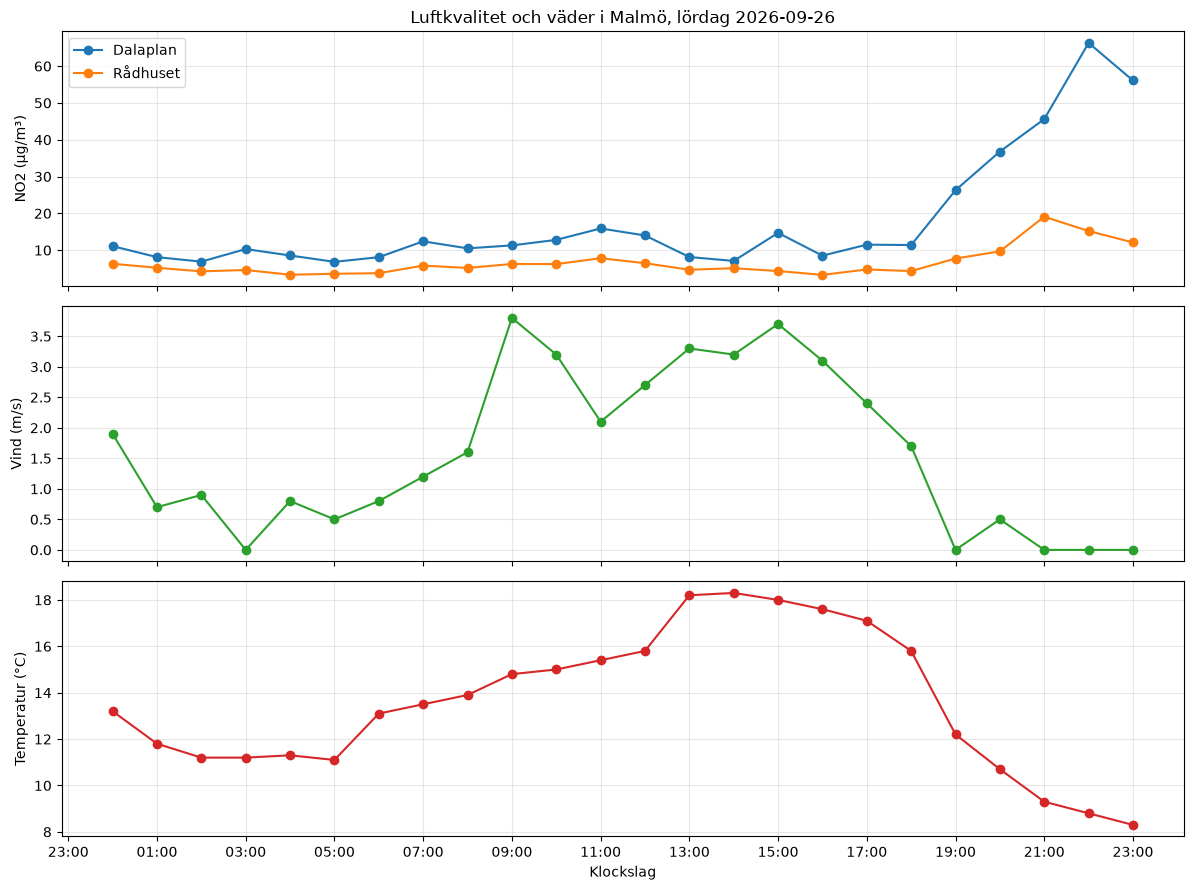

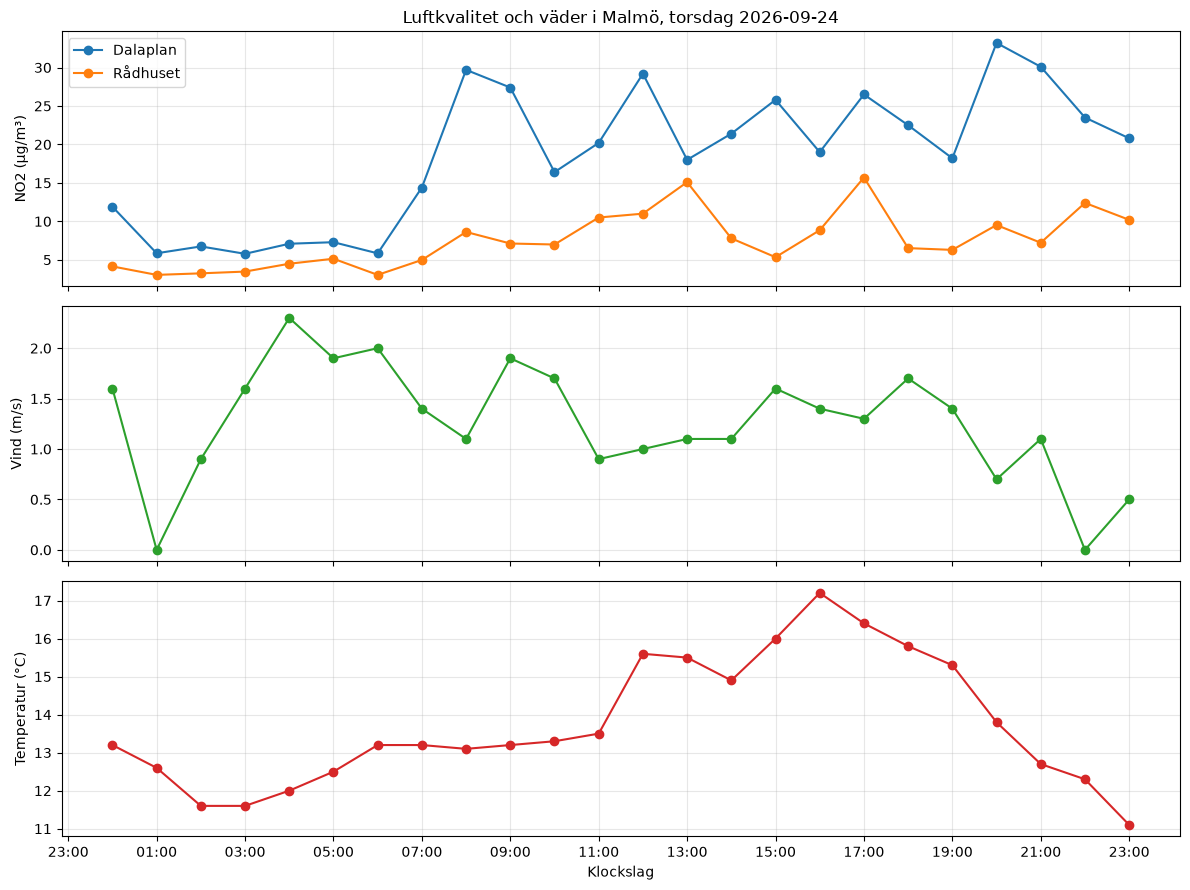

In [20]:
def rita_dygn_med_vader(dag):
    slut = (dag + timedelta(days=2)).isoformat()
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

    for _, rad in no2.iterrows():
        data = hamta(f"{BASE}/timeseries/{rad['tidsserie_id']}/getData", timespan=f"P4D/{slut}")
        df = pd.DataFrame(data["values"])
        df["tid"] = till_svensk_tid(df["timestamp"])
        df = df[df["tid"].dt.date == dag]
        ax1.plot(df["tid"], df["value"], marker="o", label=rad["plats"])

    v = vind[vind["tid"].dt.date == dag]
    ax2.plot(v["tid"], v["value"], marker="o", color="tab:green")

    t = temperatur[temperatur["tid"].dt.date == dag]
    ax3.plot(t["tid"], t["value"], marker="o", color="tab:red")

    veckodagar = ["måndag", "tisdag", "onsdag", "torsdag", "fredag", "lördag", "söndag"]
    ax1.set_title(f"Luftkvalitet och väder i Malmö, {veckodagar[dag.weekday()]} {dag.isoformat()}")
    ax1.set_ylabel("NO2 (µg/m³)")
    ax1.legend()
    ax2.set_ylabel("Vind (m/s)")
    ax3.set_ylabel("Temperatur (°C)")
    ax3.set_xlabel("Klockslag")
    ax3.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz="Europe/Stockholm"))
    for ax in (ax1, ax2, ax3):
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

rita_dygn_med_vader(date(2026, 9, 26))
rita_dygn_med_vader(date(2026, 9, 24))